In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import datetime
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [2]:
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
data_dir = project_root / "data"

candidate_dirs = [
    data_dir,
    data_dir / "StockExchangeData",
]

def resolve_csv(filename: str) -> Path:
    for folder in candidate_dirs:
        candidate = folder / filename
        if candidate.exists():
            return candidate
    searched = "\n".join(str(folder / filename) for folder in candidate_dirs)
    raise FileNotFoundError(f"Could not find {filename}. Searched:\n{searched}")

index_processed_path = resolve_csv("indexData.csv")
index_info_path = resolve_csv("indexInfo.csv")
index_processed_path = resolve_csv("indexProcessed.csv")

In [3]:
index_processed = pd.read_csv(index_processed_path, parse_dates=[1])
print("index_processed shape:", index_processed.shape)

index_processed shape: (104224, 9)


In [4]:
index_processed.info()

<class 'pandas.DataFrame'>
RangeIndex: 104224 entries, 0 to 104223
Data columns (total 9 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   Index      104224 non-null  str           
 1   Date       104224 non-null  datetime64[us]
 2   Open       104224 non-null  float64       
 3   High       104224 non-null  float64       
 4   Low        104224 non-null  float64       
 5   Close      104224 non-null  float64       
 6   Adj Close  104224 non-null  float64       
 7   Volume     104224 non-null  float64       
 8   CloseUSD   104224 non-null  float64       
dtypes: datetime64[us](1), float64(7), str(1)
memory usage: 7.2 MB


In [5]:
index_processed.head()

,Index,Date,Open,High,Low,Close,Adj Close,Volume,CloseUSD
0,HSI,1986-12-31,2568.300049,2568.300049,2568.300049,2568.300049,2568.300049,0.0,333.879006
1,HSI,1987-01-02,2540.100098,2540.100098,2540.100098,2540.100098,2540.100098,0.0,330.213013
2,HSI,1987-01-05,2552.399902,2552.399902,2552.399902,2552.399902,2552.399902,0.0,331.811987
3,HSI,1987-01-06,2583.899902,2583.899902,2583.899902,2583.899902,2583.899902,0.0,335.906987
4,HSI,1987-01-07,2607.100098,2607.100098,2607.100098,2607.100098,2607.100098,0.0,338.923013


In [6]:
index_processed['Index'].unique()

<StringArray>
[      'HSI',       'NYA',      'IXIC', '000001.SS',      'N225',      'N100',
 '399001.SZ',    'GSPTSE',      'NSEI',     'GDAXI',      'SSMI',      'TWII',
   'J203.JO']
Length: 13, dtype: str

In [7]:
index_mask = index_processed['Index'] == 'NYA'
date_mask = index_processed['Date'] >= datetime.datetime(year=2004,month=1,day=1)
nya_df = index_processed[index_mask & date_mask].set_index('Date').drop(columns=['Index', 'CloseUSD'])

# Making sure Sorted by date
nya_df = nya_df.sort_index()

nya_df.shape 

(4382, 6)

In [8]:
#Creating 3 classes (increase=1, decrease=-1, same=0)
nya_df['Target'] = 0
nya_df.loc[nya_df['Close'].shift(-1) > nya_df['Close'], 'Target'] = 1
nya_df.loc[nya_df['Close'].shift(-1) < nya_df['Close'], 'Target'] = -1


In [9]:
nya_df.shape

(4382, 7)

In [10]:
nya_df.head()

,Open,High,Low,Close,Adj Close,Volume,Target
Date,,,,,,,
2004-01-02,6464.000000,6516.129883,6438.470215,6451.259766,6451.259766,1.153200e+09,1
2004-01-05,6451.259766,6534.759766,6451.259766,6534.580078,6534.580078,1.578200e+09,1
2004-01-06,6534.580078,6546.640137,6519.270020,6541.149902,6541.149902,1.494500e+09,-1
2004-01-07,6541.149902,6541.209961,6488.270020,6525.299805,6525.299805,1.704900e+09,1
2004-01-08,6525.299805,6569.319824,6525.279785,6569.319824,6569.319824,1.868400e+09,-1


In [11]:
# Previous day's closing value - is highly correlated to MA3 and MA5 so removing it
nya_df['Last Close'] = nya_df['Close'].shift(1)

#Features for better prediction
nya_df['LowProportion'] = nya_df['Low']/nya_df['Last Close']
nya_df['HighProportion'] = nya_df['High']/nya_df['Last Close']
nya_df['DailyReturn'] = (nya_df['Close'] - nya_df['Open']) / nya_df['Open']
nya_df['VolumeReturn'] = nya_df['Volume'] * nya_df['DailyReturn']

#Average from 3 days and 5 days
nya_df['MA3'] = nya_df['Adj Close'].rolling(3).mean()

#Removing Nan values
nya_df.dropna(subset=['Target', 'Last Close', 'MA3'], inplace=True)


In [12]:
nya_df_new = nya_df.copy()

#High, Low, close, opne, adj close are highly corelated to each other, Daily return and Volumn returns are highly correlated to each other and Volume is very slightly related to target
#Drop redundant/highly correlated columns
columns_to_drop = ['High', 'Low', 'Close', 'Open', 'Adj Close', 'Last Close', 'DailyReturn', 'Volume']
nya_df_new.drop(columns=columns_to_drop, inplace=True)
nya_df_new.head()

,Target,LowProportion,HighProportion,VolumeReturn,MA3
Date,,,,,
2004-01-06,-1,0.997657,1.001846,1.502561e+06,6508.996582
2004-01-07,1,0.991916,1.000009,-4.131205e+06,6533.676595
2004-01-08,-1,0.999997,1.006746,1.260433e+07,6545.256510
2004-01-09,1,0.992054,1.000000,-1.130224e+07,6540.263184
2004-01-12,-1,0.998457,1.002996,4.051992e+06,6546.389974


,Target,LowProportion,HighProportion,VolumeReturn,MA3
Target,1.000,-0.034,-0.039,-0.043,0.005
LowProportion,-0.034,1.000,0.357,0.617,0.178
HighProportion,-0.039,0.357,1.000,0.559,-0.172
VolumeReturn,-0.043,0.617,0.559,1.000,-0.011
MA3,0.005,0.178,-0.172,-0.011,1.000


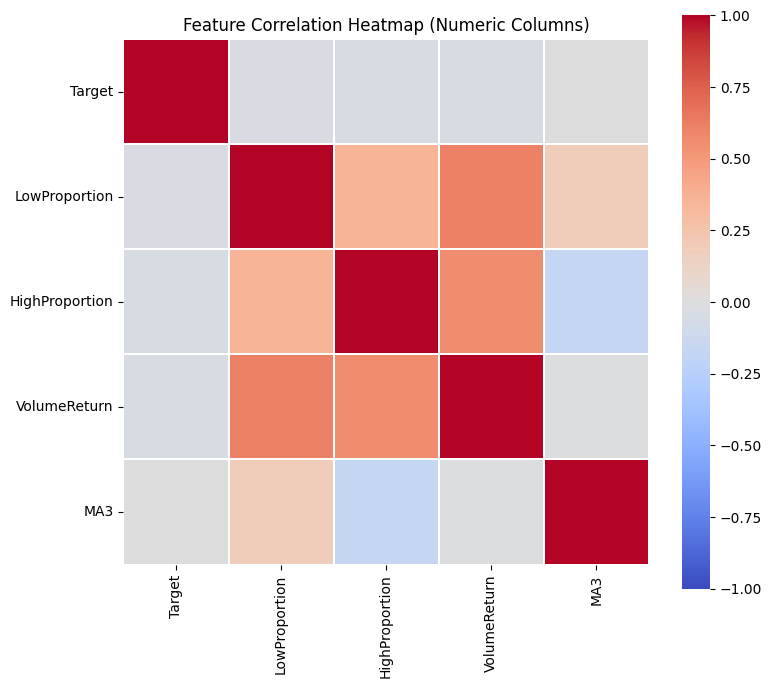

Top 10 strongest correlations (absolute):


,,correlation
LowProportion,VolumeReturn,0.616595
VolumeReturn,LowProportion,0.616595
HighProportion,VolumeReturn,0.559243
VolumeReturn,HighProportion,0.559243
LowProportion,HighProportion,0.357099
HighProportion,LowProportion,0.357099
MA3,LowProportion,0.178203
LowProportion,MA3,0.178203
MA3,HighProportion,-0.171739
HighProportion,MA3,-0.171739


In [13]:
numeric_df = nya_df_new.select_dtypes(include=[np.number]).copy()

if numeric_df.shape[1] < 2:
    print("Not enough numeric columns to compute correlation.")
else:
    corr_matrix = numeric_df.corr(numeric_only=True)
    display(corr_matrix.round(3))

    feature_count = corr_matrix.shape[0]
    fig_size = max(8, min(18, int(feature_count * 0.8)))

    plt.figure(figsize=(fig_size, fig_size))
    sns.heatmap(
        corr_matrix,
        cmap="coolwarm",
        center=0,
        vmin=-1,
        vmax=1,
        square=True,
        linewidths=0.3,
        cbar_kws={"shrink": 0.8}
    )
    plt.title("Feature Correlation Heatmap (Numeric Columns)")
    plt.tight_layout()
    plt.show()

    corr_pairs = (
        corr_matrix.where(~np.eye(corr_matrix.shape[0], dtype=bool))
        .stack()
        .sort_values(key=lambda s: s.abs(), ascending=False)
    )
    print("Top 10 strongest correlations (absolute):")
    display(corr_pairs.head(10).to_frame("correlation"))

In [14]:
#Define target
y = nya_df_new['Target']

#Define Features
X = nya_df_new.drop(columns=['Target'])

print("Feature shape:", X.shape)
print("Target shape:", y.shape)
print("Features:")
print(X.head())
print("Target:")
print(y.head())

Feature shape: (4380, 4)
Target shape: (4380,)
Features:
            LowProportion  HighProportion  VolumeReturn          MA3
Date                                                                
2004-01-06       0.997657        1.001846  1.502561e+06  6508.996582
2004-01-07       0.991916        1.000009 -4.131205e+06  6533.676595
2004-01-08       0.999997        1.006746  1.260433e+07  6545.256510
2004-01-09       0.992054        1.000000 -1.130224e+07  6540.263184
2004-01-12       0.998457        1.002996  4.051992e+06  6546.389974
Target:
Date
2004-01-06   -1
2004-01-07    1
2004-01-08   -1
2004-01-09    1
2004-01-12   -1
Name: Target, dtype: int64
